# Análisis por Hospital

Análisis descriptivo a nivel hospitalario: traslados de entrada y salida,
tiempo de internación, fallecidos, riesgo social y análisis combinado.


In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.config import *
from src.io import *
from src.procesamiento import *
from src.visualizacion import *
from src.funciones_complejas import *

import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")  # para importar desde /scripts

# from scripts import bases, init_notebook as init

In [2]:
# Cargar todos los datos del proyecto en una sola línea
ctx = init_notebook(data_path="../data")

df_pacientes   = ctx["df_pacientes"]
traslados      = ctx["traslados"]
hosp_coords    = ctx["hosp_coords"]
municipios     = ctx["municipios"]
municipios_amba = ctx["municipios_amba"]


Cargando datos de pacientes...
[reconstruir_traslados] Se descartaron 82 traslados con error grave de fechas.
  → 29,696 registros | 27,294 pacientes únicos
  → 1,681 traslados reconstruidos
Cargando datos geográficos...
  → 14 hospitales con coordenadas
  → 9 municipios AMBA cargados

✓ Entorno listo.

--- CHEQUEO POST-LIMPIEZA ---
Filas:              29696
Pacientes únicos:   27294
Hospitales únicos:  15
Valores nulos (Fecha inicio): 3168
Valores nulos (Fecha egreso): 4023

Distribución tipo_egreso:
tipo_egreso
alta           17519
traslado        5330
otro            3580
muerte          2791
desconocido      476
Name: count, dtype: int64

Distribución evolución:
evolucion
 0    27147
-1     1392
 1      944
-2      200
 2       13
Name: count, dtype: int64


## 3. Análisis Descriptivo por Hospital

### 3.1 Traslados por hospital

Top 10 hospitales que derivan más pacientes:


,traslados_out,traslados_in
UPA 5 AB,570.0,68.0
UPA 11 FV,374.0,54.0
MI PUEBLO,302.0,39.0
LUCIO MELENDEZ,113.0,103.0
MODULO HOSPITALARIO 9 AB,77.0,591.0
MODULO HOSPITALARIO 11 FV,76.0,617.0
UPA 17 QU,62.0,6.0
MODULO HOSPITALARIO 10 QU,39.0,72.0
ONATIVIA,29.0,5.0
IRIARTE,18.0,18.0



Top 10 hospitales que reciben más pacientes:


,traslados_out,traslados_in
MODULO HOSPITALARIO 11 FV,76.0,617.0
MODULO HOSPITALARIO 9 AB,77.0,591.0
EL CRUCE,15.0,103.0
LUCIO MELENDEZ,113.0,103.0
MODULO HOSPITALARIO 10 QU,39.0,72.0
UPA 5 AB,570.0,68.0
UPA 11 FV,374.0,54.0
MI PUEBLO,302.0,39.0
IRIARTE,18.0,18.0
UPA 17 QU,62.0,6.0


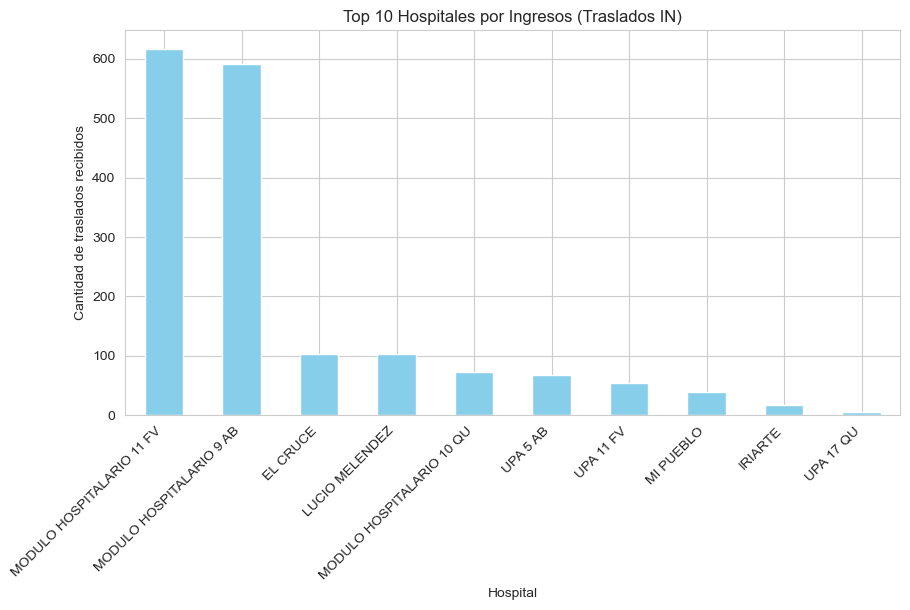

In [3]:
# Traslados OUT (Origen)
traslados_out = traslados_por_hospital(traslados, col_hospital="Nombre Hospital", graficar=False)

# Traslados IN (Destino)
traslados_in = traslados_por_hospital(traslados, col_hospital="Hospital siguiente", graficar=False)

tabla_hospitales = pd.DataFrame({
    "traslados_out": traslados_out,
    "traslados_in": traslados_in,
}).fillna(0)

print("Top 10 hospitales que derivan más pacientes:")
display(tabla_hospitales.sort_values(by="traslados_out", ascending=False).head(10))

print("\nTop 10 hospitales que reciben más pacientes:")
display(tabla_hospitales.sort_values(by="traslados_in", ascending=False).head(10))

# Graficamos los IN
tabla_hospitales["traslados_in"].sort_values(ascending=False).head(10).plot(kind="bar", color="skyblue", figsize=(10,5))
plt.title("Top 10 Hospitales por Ingresos (Traslados IN)")
plt.ylabel("Cantidad de traslados recibidos")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

In [4]:
# ESTO ES STRENGTH O FUERZA
# DEGREE: # de hospitales con los que me conecto

# fuerza/grado = numero promedio de traslados que recibo de un hospital con el que estoy conectado

### 3.2 Tiempo promedio que pasa una persona dentro del hospital

Nombre Hospital
IRIARTE                      13.772472
MODULO HOSPITALARIO 8 LZ     11.882353
MODULO HOSPITALARIO 10 QU     9.776132
ONATIVIA                      9.376883
MODULO HOSPITALARIO 11 FV     8.962939
EL CRUCE                      8.249161
MODULO HOSPITALARIO 9 AB      7.695652
MI PUEBLO                     7.645743
LUCIO MELENDEZ                7.576258
EVITA PUEBLO                  7.329577
Name: Duracion días, dtype: float64

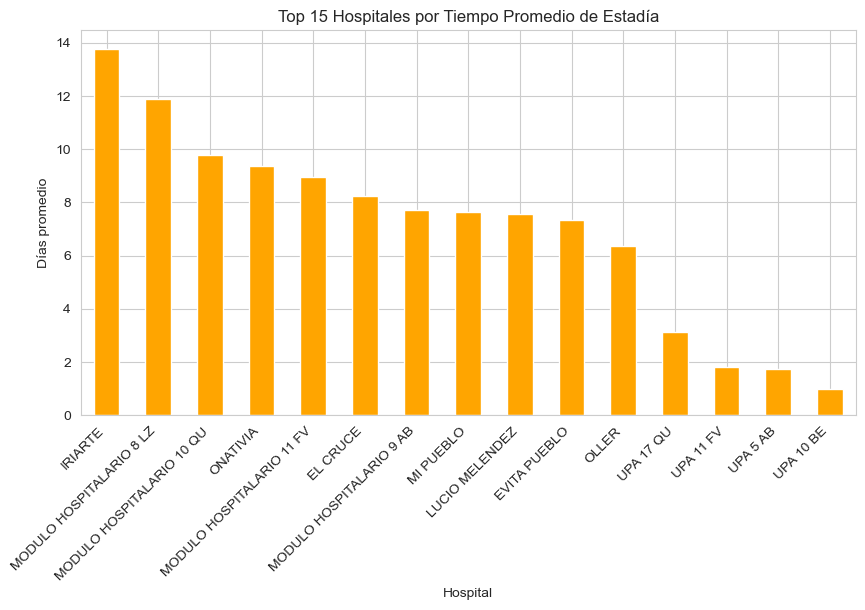

In [5]:
# Tiempo promedio por hospital
tiempo_prom_hosp = tiempo_promedio_por_hospital(df_pacientes, col_hospital="Nombre Hospital", col_dias="Duracion días", quantile_outlier=0.95, graficar=False)

display(tiempo_prom_hosp.head(10))

tiempo_prom_hosp.head(15).plot(kind="bar", color="orange", figsize=(10,5))
plt.title("Top 15 Hospitales por Tiempo Promedio de Estadía")
plt.ylabel("Días promedio")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

In [6]:
# agregar los valores a las barras

### 3.3 Cantidad de muertos por hospital

Nombre Hospital
ONATIVIA                     595
EVITA PUEBLO                 341
IRIARTE                      323
MI PUEBLO                    311
LUCIO MELENDEZ               308
MODULO HOSPITALARIO 11 FV    278
MODULO HOSPITALARIO 10 QU    184
MODULO HOSPITALARIO 9 AB     151
EL CRUCE                     141
UPA 5 AB                      89
dtype: int64

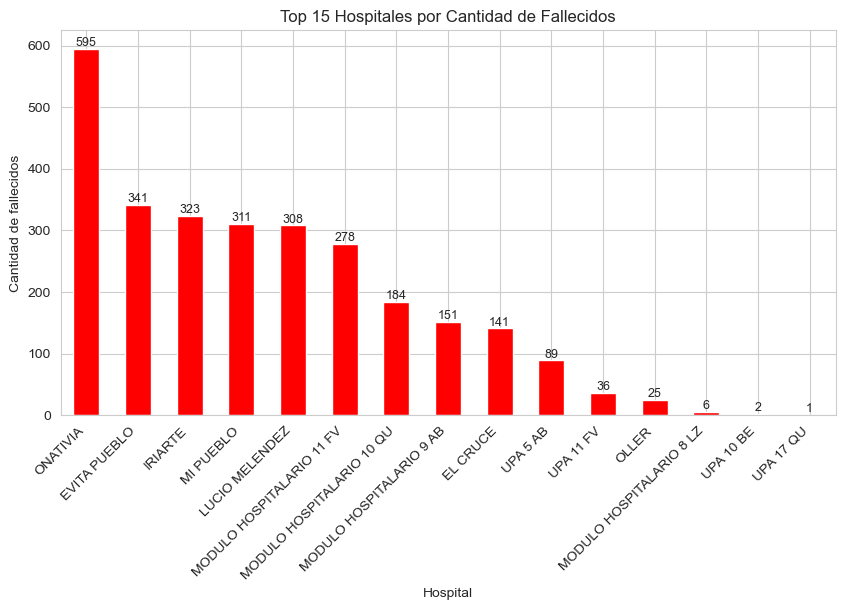

In [7]:
muertes_hosp = muertes_por_hospital(
    df_pacientes,
    col_hospital="Nombre Hospital",
    col_muerte="murio",
    graficar=False
)

display(muertes_hosp.head(10))

ax = muertes_hosp.head(15).plot(kind="bar", color="red", figsize=(10,5))

# agregar numerito arriba de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Top 15 Hospitales por Cantidad de Fallecidos")
plt.ylabel("Cantidad de fallecidos")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

In [8]:
## entrar a la red o volver a casa o muerte
## version: optimista


# ver que rol tienen estos indicadores en la caminata

In [9]:
## ver los cambios de estado de las personas
## cuanta gente pasa de estado general a critico, intermedio a general, etc etc

## traslados entre hospitales  y traslados entre niveles
# la gente mejora o empeora en el hospital? cuantos?

## 4. Análisis Combinado

### 4.1 Cantidad de personas con distintos niveles de riesgo social y estados (crítico, intermedio general)

Estado al ingreso,ocupadas_covid,ocupadas_otros,sospechosos,Total
Nivel riesgo social,,,,
no,3404,10426,3402,17232
si,2353,1235,2373,5961
Total,5757,11661,5775,23193


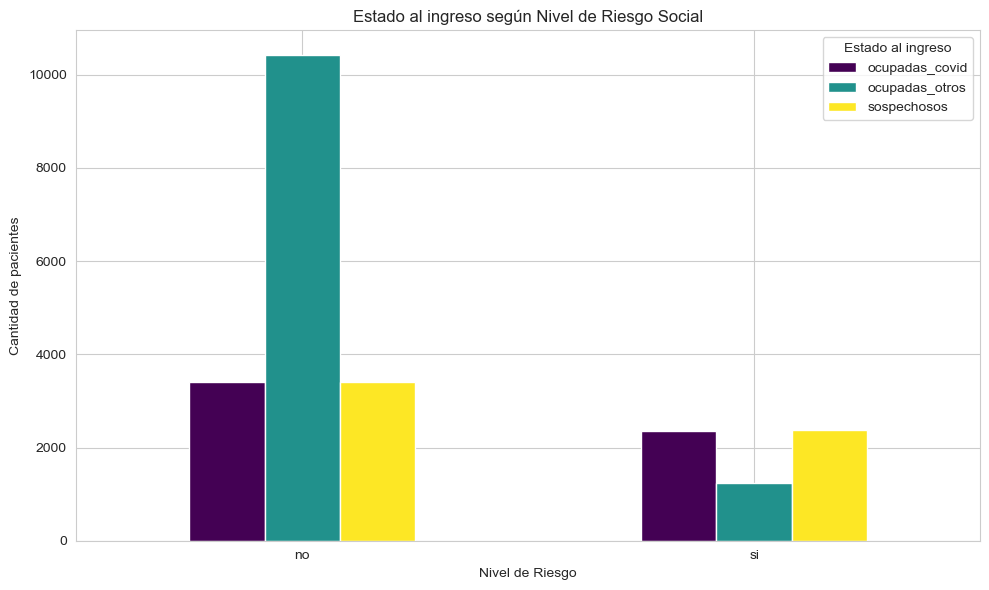

In [10]:
# Tabla cruzada de Nivel de riesgo social y Estado al ingreso
# Tabla cruzada de Nivel de riesgo social y Estado al ingreso
if "Nivel riesgo social" in df_pacientes.columns and "Estado al ingreso" in df_pacientes.columns:

    tabla_riesgo_estado = pd.crosstab(
        df_pacientes["Nivel riesgo social"],
        df_pacientes["Estado al ingreso"],
        margins=True,
        margins_name="Total"
    )

    display(tabla_riesgo_estado)

    tabla_sin_totales = pd.crosstab(
        df_pacientes["Nivel riesgo social"],
        df_pacientes["Estado al ingreso"]
    )

    tabla_sin_totales.plot(
        kind="bar",
        stacked=False,
        figsize=(10,6),
        colormap="viridis"
    )

    plt.title("Estado al ingreso según Nivel de Riesgo Social")
    plt.ylabel("Cantidad de pacientes")
    plt.xlabel("Nivel de Riesgo")
    plt.xticks(rotation=0)
    plt.legend(title="Estado al ingreso")
    plt.tight_layout()
    plt.show()

else:
    print("Las columnas necesarias para este análisis no están disponibles.")
    print("Columnas disponibles:", df_pacientes.columns.tolist())

### 4.2 Relacionar Secciones (Tiempos vs. Riesgo Social / Estado)

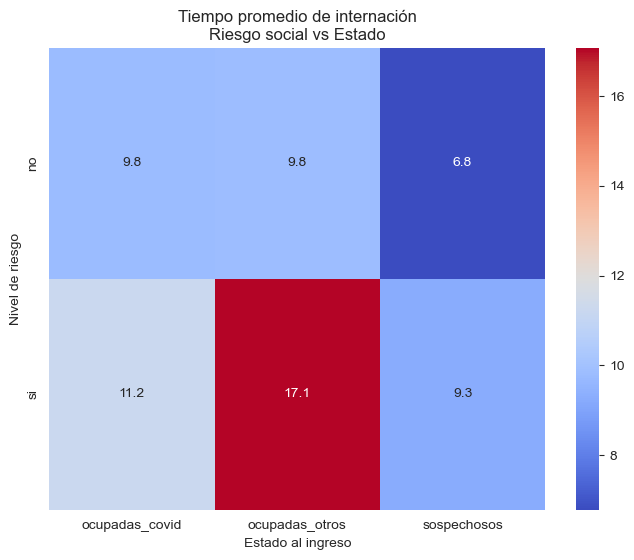

Estado al ingreso,ocupadas_covid,ocupadas_otros,sospechosos
Nivel riesgo social,,,
no,9.785965,9.815471,6.783468
si,11.242630,17.071625,9.259243


In [12]:
relacion_tiempo_riesgo_estado(df_pacientes)